# Hierarchical Clustering: Agglomerative and Divisive
**Practical assignment — Python / Jupyter Notebook**

Name: ____________________   Roll number: ____________________

## Aim
Implement and compare bottom-up agglomerative clustering and top-down divisive clustering, visualize their hierarchies, and evaluate the resulting groups.

Run the code cells in order using **Shift + Enter**, or select **Run All**. The notebook includes executed outputs. It uses the built-in Iris dataset; no dataset download is needed.

## 1. Concepts
Hierarchical clustering creates nested groups based on similarity. A dendrogram displays these relationships.

| Feature | Agglomerative | Divisive |
|---|---|---|
| Direction | Bottom-up | Top-down |
| Starting state | Each observation is a separate cluster | All observations are in one cluster |
| Main operation | Merge two clusters | Split one cluster into two |
| Implementation here | Ward linkage | DIANA-style diameter selection and splinter splitting |
| Final partition | Stop merging at the chosen number of groups | Stop splitting at the chosen number of groups |

Ward selects the merge with the smallest increase in within-cluster squared error. The divisive method here splits the cluster with the largest diameter. These are different objectives, so their results need not match.

## 2. Install packages if necessary
Uncomment and run the next line only if a package is missing. Restart the kernel after installation, then run the notebook again.

In [1]:
# %pip install numpy pandas matplotlib scipy scikit-learn

## 3. Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 10})
print('Libraries imported successfully.')

Libraries imported successfully.


## 4. Load and inspect Iris
There are 150 flowers and four numeric measurements. Species labels are used **only for evaluation**, never to fit either clustering method. We choose three clusters as a teaching example because Iris has three known species; in an unlabeled problem the number would need investigation.

In [3]:
iris = load_iris()
X = iris.data
y_true = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
print('Dataset shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
display(df.head())

Dataset shape: (150, 4)
Missing values: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 5. Standardize the features
Distances can be dominated by features with larger scales. Standardization gives each feature mean approximately zero and standard deviation approximately one.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
N_CLUSTERS = 3
print('Feature means:', np.round(X_scaled.mean(axis=0), 3))
print('Feature standard deviations:', np.round(X_scaled.std(axis=0), 3))

Feature means: [-0. -0. -0. -0.]
Feature standard deviations: [1. 1. 1. 1.]


## 6. Agglomerative clustering
1. Begin with one cluster per flower.
2. Use Ward linkage to choose and merge two groups.
3. Continue until three clusters remain.

Ward linkage uses Euclidean geometry.

In [5]:
agg_model = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)
print('Agglomerative cluster sizes:')
print(pd.Series(agg_labels).value_counts().sort_index().to_string())

Agglomerative cluster sizes:
0    71
1    49
2    30


## 7. Agglomerative dendrogram
SciPy builds the complete Ward hierarchy on the same standardized data. The figure shows the last 15 merged groups for readability. Parenthesized labels represent groups of observations. Read bottom to top to follow the merges.

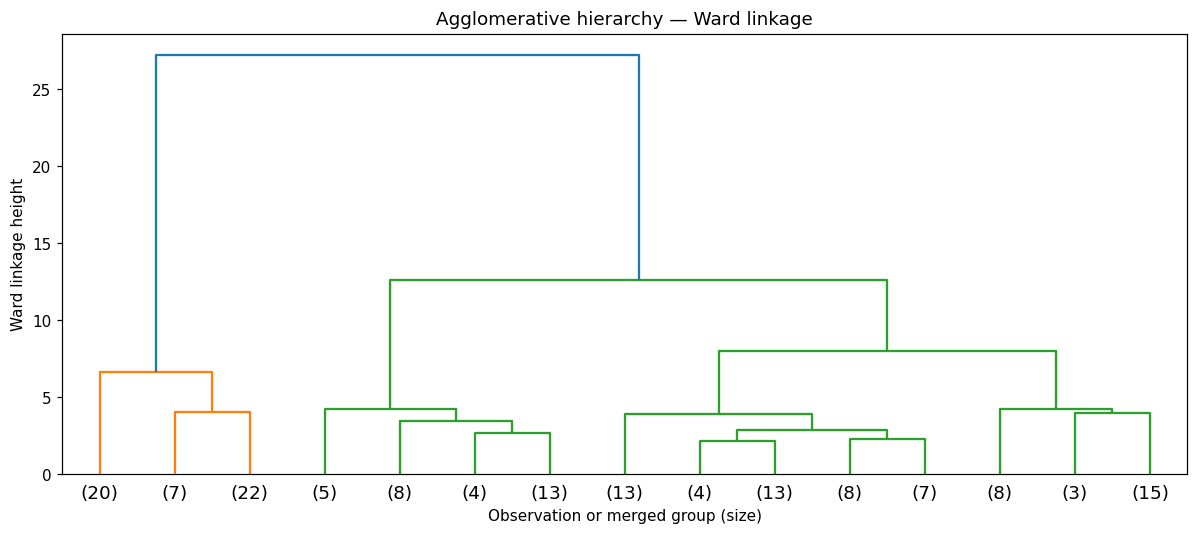

In [6]:
Z_agg = linkage(X_scaled, method='ward')
plt.figure(figsize=(11, 5))
dendrogram(Z_agg, truncate_mode='lastp', p=15, show_leaf_counts=True)
plt.title('Agglomerative hierarchy — Ward linkage')
plt.xlabel('Observation or merged group (size)')
plt.ylabel('Ward linkage height')
plt.tight_layout()
plt.show()

## 8. Divisive clustering: implement the splitting rule
This educational implementation follows DIANA's main splitting rules:

1. Start with all observations together.
2. Choose the non-singleton cluster with the largest diameter (maximum pairwise distance).
3. Start a new **splinter group** with the observation having the highest average distance to other members.
4. For each remaining observation, calculate its average distance to the remaining group (excluding itself) minus its average distance to the splinter group.
5. Move the observation with the largest positive difference into the splinter group. Repeat until none has a positive difference.
6. Continue splitting to singleton clusters, retaining the partition at the requested number of groups.

The distance matrix uses quadratic memory, so this simple implementation is intended for small datasets. Ties use the first encountered member.

In [7]:
def splinter_split(members, distances):
    """Divide one non-singleton cluster into two non-empty groups."""
    members = list(members)
    within = distances[np.ix_(members, members)]
    mean_distances = within.sum(axis=1) / (len(members) - 1)
    seed = members[int(np.argmax(mean_distances))]
    splinter = [seed]
    remaining = [i for i in members if i != seed]

    while len(remaining) > 1:
        differences = []
        for i in remaining:
            others = [j for j in remaining if j != i]
            to_remaining = distances[i, others].mean()
            to_splinter = distances[i, splinter].mean()
            differences.append(to_remaining - to_splinter)
        best = int(np.argmax(differences))
        if differences[best] <= 0:
            break
        splinter.append(remaining.pop(best))
    return remaining, splinter


def divisive_clustering(data, n_clusters=3):
    """Return chosen labels, full split tree, and chronological split history."""
    data = np.asarray(data, dtype=float)
    if data.ndim != 2 or len(data) < 2 or not np.isfinite(data).all():
        raise ValueError('Provide at least two rows of finite numeric features.')
    n = len(data)
    if not isinstance(n_clusters, (int, np.integer)) or not 1 <= n_clusters <= n:
        raise ValueError('n_clusters must be an integer between 1 and n_samples.')
    distances = squareform(pdist(data, metric='euclidean'))
    root = tuple(range(n))
    active = [root]
    tree, history = {}, []
    chosen = list(active) if n_clusters == 1 else None

    while len(active) < n:
        candidates = [(float(distances[np.ix_(c, c)].max()), pos)
                      for pos, c in enumerate(active) if len(c) > 1]
        diameter, position = max(candidates, key=lambda item: item[0])
        parent = active.pop(position)
        left, right = splinter_split(parent, distances)
        left, right = tuple(left), tuple(right)
        tree[parent] = (left, right, diameter)
        active.extend([left, right])
        history.append({'step': len(history) + 1, 'parent_size': len(parent),
                        'left_size': len(left), 'right_size': len(right),
                        'diameter': diameter, 'clusters_after_split': len(active)})
        if len(active) == n_clusters:
            chosen = list(active)

    labels = np.empty(n, dtype=int)
    for label, members in enumerate(chosen):
        labels[list(members)] = label
    return labels, tree, pd.DataFrame(history)


def divisive_linkage(tree, n_samples):
    """Encode the split tree in SciPy format for dendrogram visualization."""
    rows = []
    def visit(node):
        if len(node) == 1:
            return node[0]
        left, right, height = tree[node]
        left_id = visit(left)
        right_id = visit(right)
        node_id = n_samples + len(rows)
        rows.append([left_id, right_id, height, len(node)])
        return node_id
    visit(tuple(range(n_samples)))
    return np.asarray(rows, dtype=float)

print('Divisive clustering functions are ready.')

Divisive clustering functions are ready.


## 9. Run divisive clustering and inspect the split history

In [8]:
div_labels, div_tree, split_history = divisive_clustering(X_scaled, N_CLUSTERS)
print('Divisive cluster sizes:')
print(pd.Series(div_labels).value_counts().sort_index().to_string())
print('First five splits (the first two produce our three-cluster partition):')
display(split_history.head())

Divisive cluster sizes:
0    50
1    56
2    44
First five splits (the first two produce our three-cluster partition):


,step,parent_size,left_size,right_size,diameter,clusters_after_split
0,1,150,100,50,6.529323,2
1,2,100,56,44,5.828015,3
2,3,50,24,26,5.051063,4
3,4,44,41,3,3.216237,5
4,5,41,32,9,3.216237,6


## 10. Divisive dendrogram
Read from top to bottom to follow splitting. Height is the parent cluster's diameter, not Ward's merge height. The two diagrams therefore have different height meanings. The stored tree is converted for plotting; it is not produced by reversing Ward's clustering.

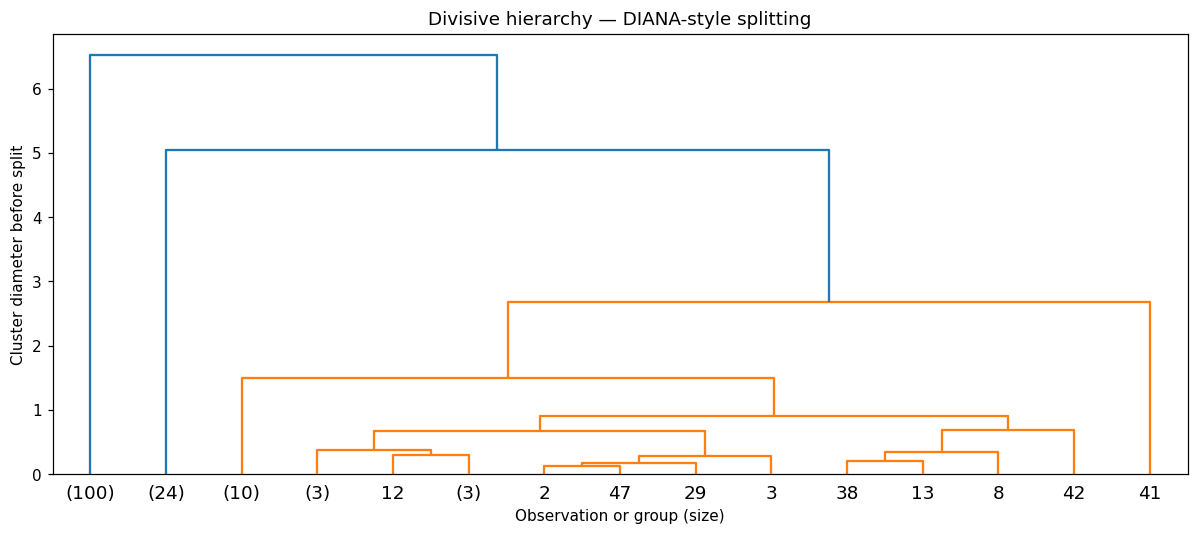

In [9]:
Z_div = divisive_linkage(div_tree, len(X_scaled))
plt.figure(figsize=(11, 5))
dendrogram(Z_div, truncate_mode='lastp', p=15, show_leaf_counts=True)
plt.title('Divisive hierarchy — DIANA-style splitting')
plt.xlabel('Observation or group (size)')
plt.ylabel('Cluster diameter before split')
plt.tight_layout()
plt.show()

## 11. Visualize both partitions
Both algorithms use all four standardized features. PCA reduces them to two dimensions **only for plotting**, so some separation can be lost. Cluster numbers and colors are arbitrary; cluster 0 need not mean the same group in both methods.

Variance represented by the 2D plot: 95.8%


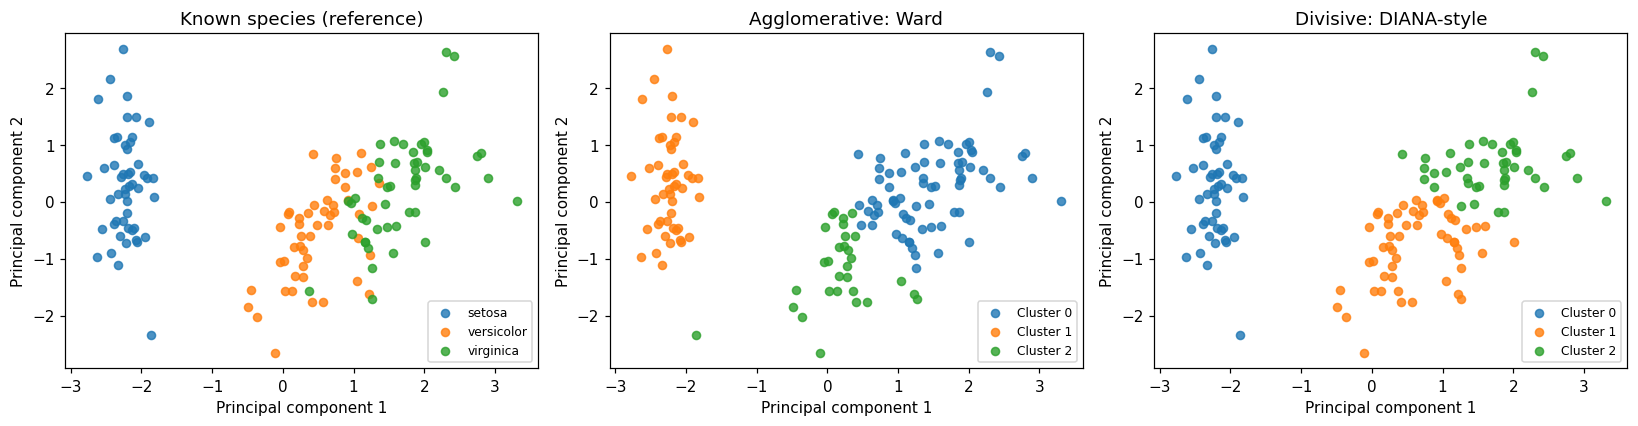

In [10]:
pca = PCA(n_components=2)
X_plot = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, labels, title in zip(axes, [y_true, agg_labels, div_labels],
                           ['Known species (reference)', 'Agglomerative: Ward', 'Divisive: DIANA-style']):
    for group in np.unique(labels):
        mask = labels == group
        name = iris.target_names[group] if title.startswith('Known') else f'Cluster {group}'
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], label=name, s=28, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Principal component 1')
    ax.set_ylabel('Principal component 2')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Variance represented by the 2D plot: {pca.explained_variance_ratio_.sum():.1%}')

## 12. Compare performance
- **Silhouette score:** measures compactness and separation using features; higher is better (range −1 to 1).
- **Adjusted Rand index (ARI):** compares a partition with the known species; 1 is perfect agreement and approximately 0 is chance-level agreement. Negative values are possible. It does not require matching cluster numbers to species numbers.

These scores describe this dataset and preprocessing; they do not prove one method is universally better.

In [11]:
comparison = pd.DataFrame([
    {'Method': name, 'Clusters': len(np.unique(labels)),
     'Silhouette': silhouette_score(X_scaled, labels),
     'ARI vs species': adjusted_rand_score(y_true, labels)}
    for name, labels in [('Agglomerative (Ward)', agg_labels),
                         ('Divisive (DIANA-style)', div_labels)]
])
display(comparison.round(4))
assignments = df.copy()
assignments['Species'] = iris.target_names[y_true]
assignments['Agglomerative cluster'] = agg_labels
assignments['Divisive cluster'] = div_labels
display(assignments.head(10))
best = comparison.loc[comparison['Silhouette'].idxmax(), 'Method']
print('Higher silhouette score in this run:', best)

Higher silhouette score in this run: Divisive (DIANA-style)


,Method,Clusters,Silhouette,ARI vs species
0,Agglomerative (Ward),3,0.4467,0.6153
1,Divisive (DIANA-style),3,0.4630,0.5923


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,Agglomerative cluster,Divisive cluster
0,5.1,3.5,1.4,0.2,setosa,1,0
1,4.9,3.0,1.4,0.2,setosa,1,0
2,4.7,3.2,1.3,0.2,setosa,1,0
3,4.6,3.1,1.5,0.2,setosa,1,0
4,5.0,3.6,1.4,0.2,setosa,1,0
5,5.4,3.9,1.7,0.4,setosa,1,0
6,4.6,3.4,1.4,0.3,setosa,1,0
7,5.0,3.4,1.5,0.2,setosa,1,0
8,4.4,2.9,1.4,0.2,setosa,1,0
9,4.9,3.1,1.5,0.1,setosa,1,0


## 13. Verify the implementation
Check that each split preserves all members and that both final partitions contain the requested number of groups. Test the divisive method on a tiny dataset with two clearly separated pairs.

In [12]:
assert len(np.unique(agg_labels)) == N_CLUSTERS
assert len(np.unique(div_labels)) == N_CLUSTERS
assert len(div_tree) == len(X_scaled) - 1
for parent, (left, right, height) in div_tree.items():
    assert left and right
    assert set(left).isdisjoint(right)
    assert set(left) | set(right) == set(parent)
tiny = np.array([[0.0], [0.1], [10.0], [10.1]])
tiny_labels, _, _ = divisive_clustering(tiny, 2)
assert tiny_labels[0] == tiny_labels[1]
assert tiny_labels[2] == tiny_labels[3]
assert tiny_labels[0] != tiny_labels[2]
for k in [1, len(tiny)]:
    labels, _, _ = divisive_clustering(tiny, k)
    assert len(np.unique(labels)) == k
print('All partition and splitting checks passed.')

All partition and splitting checks passed.


## Result and conclusion
Both types of hierarchical clustering have been implemented and visualized. Agglomerative clustering constructs groups through repeated merges; divisive clustering constructs them through repeated splits. The displayed comparison reports the actual results for the standardized Iris dataset.

**Limitations:** Results depend on scaling, distance, linkage or splitting rules, and the chosen number of clusters. Species need not form perfectly separated distance-based groups. The custom divisive implementation is educational and is not optimized for large datasets.

## Submission steps
1. Fill in your name and roll number at the top.
2. Open this file in Jupyter Notebook and run all cells, then save it.
3. Upload the `.ipynb` file to the platform your teacher requires (for example, a GitHub repository).
4. Copy the uploaded notebook's accessible link and paste it into the Google Form supplied by your teacher.

No Google Form URL was provided, so this notebook has not been submitted.

## References
- [scikit-learn: AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)
- [R cluster documentation: DIANA algorithm](https://stat.ethz.ch/R-manual/R-devel/library/cluster/html/diana.html)
- [SciPy: dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html)
